# Personal Finance & Expense Analysis — OSEMN Walkthrough

**Author:** Tarun · **Framework:** OSEMN (Obtain → Scrub → Explore → Model → iNterpret)

**Goal.** Track and analyze monthly spending to answer:
- How much am I spending each month?
- Which categories take most of my money?
- Are my expenses increasing over time?
- Where can I reduce spending?

**Dataset.** Real personal transaction feed (`expenses.csv`) extracted from
`Expenses.numbers`, spanning **Dec 12 2025 → Mar 24 2026** (≈3.5 months,
121 rows). Fields: `TransactionID`, `Date`, `Description`, `Category`
(consolidated), `Category_Raw` (original label, kept for audit), `Amount`,
`Payment Method`, `IsOneOff` (flag for non-recurring charges).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

## 1 · Obtain — load the transaction feed

In [2]:
df = pd.read_csv("expenses.csv", parse_dates=["Date"])
print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head()

Rows: 121   Columns: 12
Date range: 2025-12-12 → 2026-03-24


,TransactionID,Date,Year,Month,YearMonth,Description,Category,Category_Raw,Amount,Payment Method,Weekday,IsOneOff
0,T0001,2025-12-12,2025,12,2025-12,Adidas US Online Store,Shopping,Merchandise,105.00,Discover Card,Friday,No
1,T0002,2025-12-24,2025,12,2025-12,Desi Chowrastha Nashua NH,Restaurants,Restaurants,78.07,Discover Card,Wednesday,No
2,T0003,2025-12-28,2025,12,2025-12,Nike.com,Shopping,Merchandise,165.00,Discover Card,Sunday,No
3,T0004,2025-12-30,2025,12,2025-12,Milkshake Lovers Nashua NH,Restaurants,Restaurants,7.74,Discover Card,Tuesday,No
4,T0005,2025-12-30,2025,12,2025-12,Desi Chowrastha Nashua NH,Restaurants,Restaurants,40.12,Discover Card,Tuesday,No


## 2 · Scrub — clean, validate, enrich

In [3]:
# Type / integrity checks
print("Missing values per column:")
print(df.isna().sum())

print(f"\nDuplicate TransactionIDs: {df['TransactionID'].duplicated().sum()}")
print(f"Negative amounts (should be 0 for an expense feed): {(df['Amount'] < 0).sum()}")
print(f"Unique categories: {df['Category'].nunique()}")
print(f"Unique payment methods: {df['Payment Method'].nunique()}")

Missing values per column:
TransactionID     0
Date              0
Year              0
Month             0
YearMonth         0
Description       0
Category          0
Category_Raw      0
Amount            0
Payment Method    0
Weekday           0
IsOneOff          0
dtype: int64

Duplicate TransactionIDs: 0
Negative amounts (should be 0 for an expense feed): 0
Unique categories: 15
Unique payment methods: 2


In [4]:
# Fixing the one data issue caught during ingest:
#   4 rows in the source file were dated 2026-12-31 but sit BETWEEN
#   2025-12-30 and 2026-01-01 — obvious typo, corrected to 2025-12-31
#   in clean_data.py. Verify here:
print("Rows in Dec 2025:", (df['YearMonth'] == '2025-12').sum())
print("Rows in Dec 2026 (should be 0):", (df['YearMonth'] == '2026-12').sum())

# Time features are already present from clean_data.py, confirm:
df[["Date","Year","Month","YearMonth","Weekday"]].head()

Rows in Dec 2025: 12
Rows in Dec 2026 (should be 0): 0


,Date,Year,Month,YearMonth,Weekday
0,2025-12-12,2025,12,2025-12,Friday
1,2025-12-24,2025,12,2025-12,Wednesday
2,2025-12-28,2025,12,2025-12,Sunday
3,2025-12-30,2025,12,2025-12,Tuesday
4,2025-12-30,2025,12,2025-12,Tuesday


In [5]:
# Category consolidation audit — clean_data.py collapsed a handful of
# near-synonym labels (Supermarkets→Groceries, Gas/Convenience+Convenience
# Store→Gasoline, Merchandise→Shopping, Online Services→Subscriptions).
# The original label is preserved in Category_Raw so we can audit.
remap = df[df['Category'] != df['Category_Raw']]
(remap.groupby(['Category_Raw','Category']).size()
      .reset_index(name='rows')
      .sort_values('rows', ascending=False))

,Category_Raw,Category,rows
1,Gas/Convenience,Gasoline,7
3,Online Services,Subscriptions,3
0,Convenience Store,Gasoline,2
2,Merchandise,Shopping,2
4,Supermarkets,Groceries,1


In [6]:
# One-off flagging — clean_data.py marks transactions that are NOT part of the
# recurring monthly pattern (visa fees, court fines, annual subscription
# renewals, one-time tourist visits, bimonthly utility lumps). These rows
# distort the month-over-month picture when they land; flagging them lets us
# compute the "recurring baseline" separately.
one_off = df[df['IsOneOff'] == 'Yes']
print(f"One-off transactions: {len(one_off)} of {len(df)} "
      f"({len(one_off)/len(df)*100:.1f}% of rows)")
print(f"One-off amount:       ${one_off['Amount'].sum():,.2f} of "
      f"${df['Amount'].sum():,.2f} "
      f"({one_off['Amount'].sum()/df['Amount'].sum()*100:.1f}% of spend)")
(one_off.groupby(['Category','Description'])['Amount']
        .agg(['sum','count'])
        .round(2)
        .sort_values('sum', ascending=False))

One-off transactions: 9 of 121 (7.4% of rows)
One-off amount:       $1,797.61 of $4,506.53 (39.9% of spend)


,,sum,count
Category,Description,,
Government,USCIS I-765 Fee,470.00,1
Utilities,Eversource Utility Bill,460.07,2
Subscriptions,Mint Mobile Subscription,267.12,1
Entertainment,Summit One Vanderbilt NY,262.40,2
Fines/Legal,Schoharie Town Court NY,168.00,1
Shopping,Abercrombie & Fitch Burlington MA,165.00,1
Fines/Legal,Schoharie Court Fee,5.02,1


## 3 · Explore — where is the money going?

In [7]:
# Headline KPIs
total       = df["Amount"].sum()
months      = df["YearMonth"].nunique()
monthly_avg = total / months
top_cat     = df.groupby("Category")["Amount"].sum().idxmax()
biggest_txn = df.loc[df["Amount"].idxmax()]

print(f"Total spend:                ${total:>12,.2f}")
print(f"Months covered:             {months:>12}")
print(f"Monthly average:            ${monthly_avg:>12,.2f}")
print(f"Transactions:               {len(df):>12,}")
print(f"Top category overall:       {top_cat}")
print(f"Largest single transaction: ${biggest_txn['Amount']:,.2f} "
      f"({biggest_txn['Description']}, {biggest_txn['Date'].date()})")

Total spend:                $    4,506.53
Months covered:                        4
Monthly average:            $    1,126.63
Transactions:                        121
Top category overall:       Shopping
Largest single transaction: $470.00 (USCIS I-765 Fee, 2026-01-07)


In [8]:
# Spend by category
cat_totals = (df.groupby("Category")["Amount"]
                .agg(Total="sum", Count="count", AvgTxn="mean")
                .sort_values("Total", ascending=False)
                .round(2))
cat_totals["Share"] = (cat_totals["Total"] / cat_totals["Total"].sum()).map("{:.1%}".format)
cat_totals

,Total,Count,AvgTxn,Share
Category,,,,
Shopping,723.47,12,60.29,16.1%
Restaurants,666.68,26,25.64,14.8%
Groceries,620.41,19,32.65,13.8%
Government,470.00,1,470.00,10.4%
Utilities,460.07,2,230.04,10.2%
Subscriptions,384.56,8,48.07,8.5%
Entertainment,304.40,3,101.47,6.8%
Gasoline,259.70,14,18.55,5.8%
Fines/Legal,173.02,2,86.51,3.8%


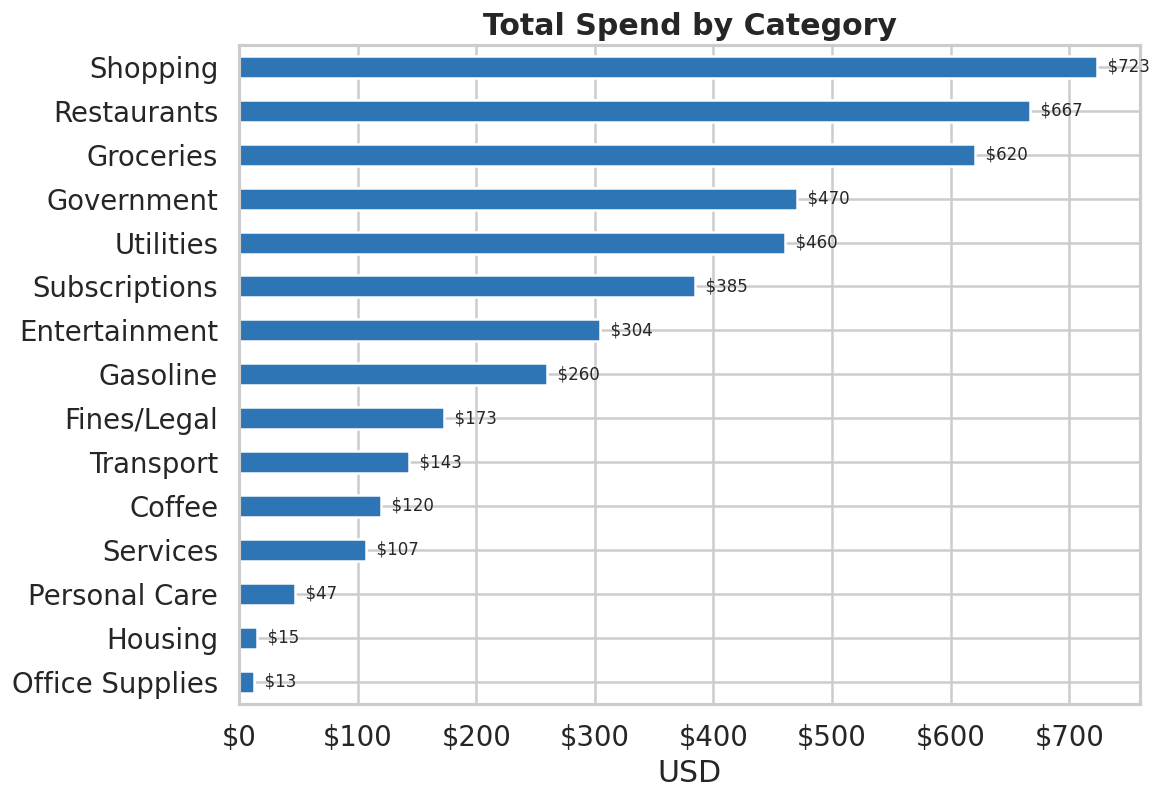

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
cat_totals["Total"].sort_values().plot.barh(ax=ax, color="#2E75B6")
ax.set_title("Total Spend by Category")
ax.set_xlabel("USD")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for i, v in enumerate(cat_totals["Total"].sort_values()):
    ax.text(v, i, f"  ${v:,.0f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("figures/01_spend_by_category.png", dpi=140, bbox_inches="tight")
plt.show()

In [10]:
# Month-over-month trend (only 4 months of data so we skip rolling avg)
monthly = (df.groupby("YearMonth", as_index=False)["Amount"]
             .agg(Spend="sum", Transactions="count")
             .round(2))
monthly["AvgPerTxn"] = (monthly["Spend"] / monthly["Transactions"]).round(2)
monthly

,YearMonth,Spend,Transactions,AvgPerTxn
0,2025-12,713.69,12,59.47
1,2026-01,2169.56,63,34.44
2,2026-02,1348.56,37,36.45
3,2026-03,274.72,9,30.52


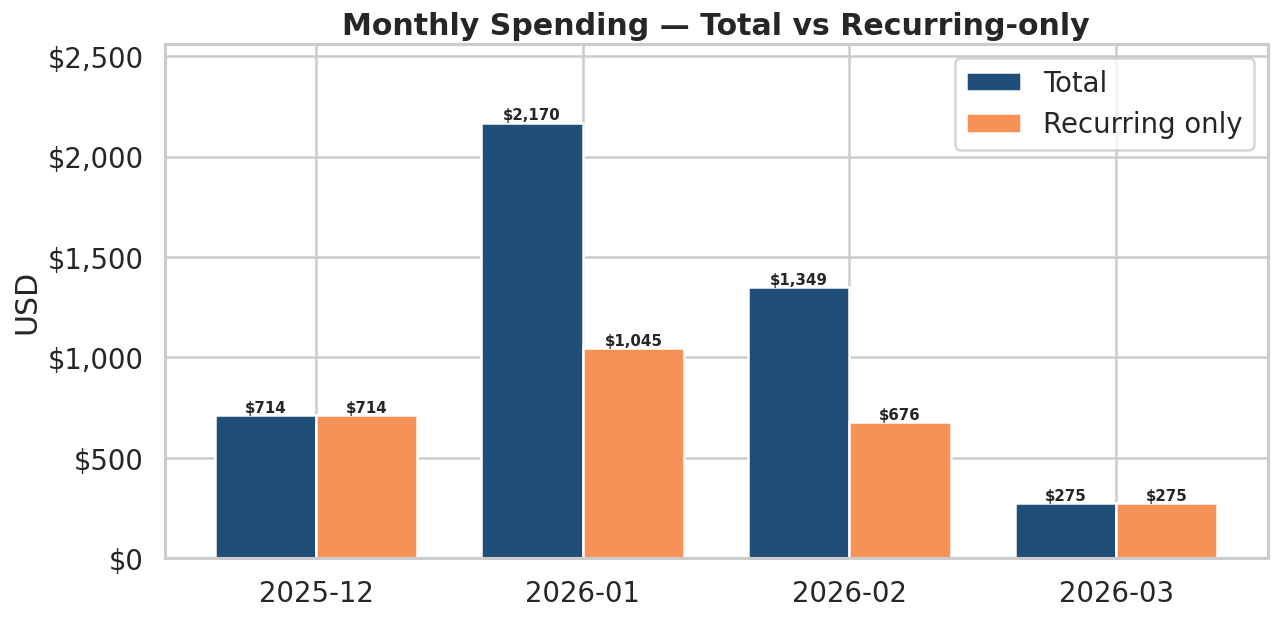

In [11]:
# Monthly spending — Total vs Recurring-only (strips one-offs).
# This is the single most important visual in the whole analysis: Jan looked
# like a $2.2k month until you strip the USCIS fee, Mint Mobile renewal, and
# Summit One Vanderbilt trip — the recurring baseline is ~$1k.
recur = df[df['IsOneOff'] == 'No']
monthly_recur = (recur.groupby('YearMonth')['Amount'].sum()
                      .reindex(monthly['YearMonth']).values)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(monthly))
w = 0.38
bars_total = ax.bar(x - w/2, monthly["Spend"],  w, label="Total",          color="#1F4E78")
bars_recur = ax.bar(x + w/2, monthly_recur,     w, label="Recurring only", color="#F79256")

ax.set_xticks(x); ax.set_xticklabels(monthly["YearMonth"])
ax.set_title("Monthly Spending — Total vs Recurring-only")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(loc="upper right")
for bars, vals in [(bars_total, monthly["Spend"]), (bars_recur, monthly_recur)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f"${v:,.0f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(0, max(monthly["Spend"].max(), max(monthly_recur)) * 1.18)
plt.tight_layout()
plt.savefig("figures/02_monthly_trend.png", dpi=140, bbox_inches="tight")
plt.show()

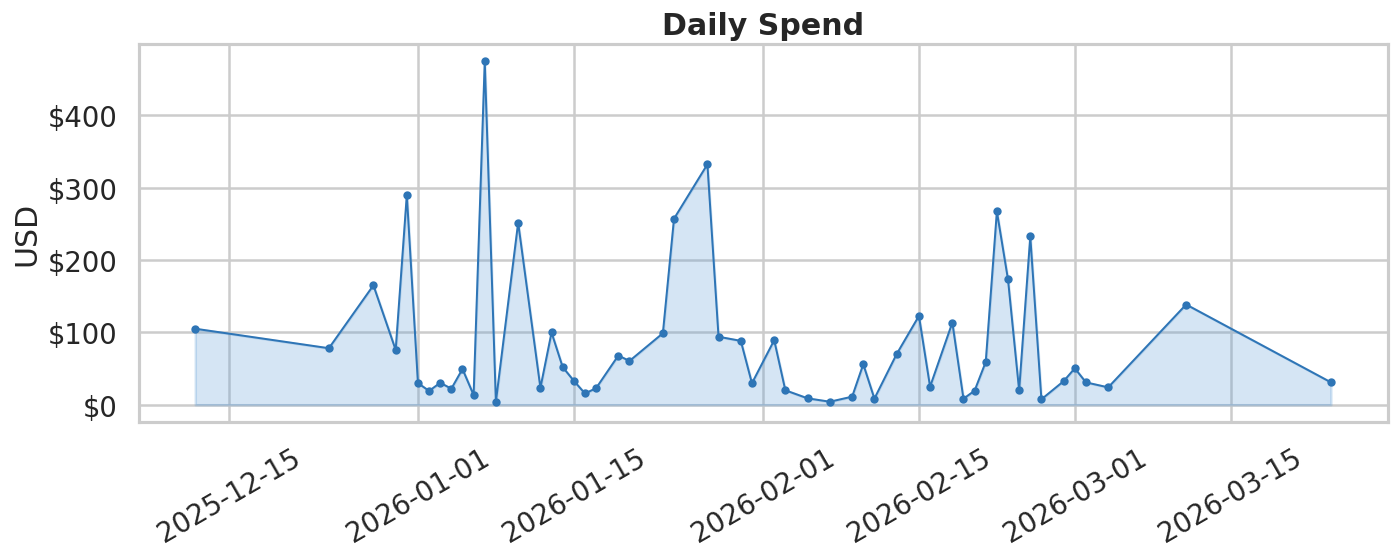

In [12]:
# Daily spend over the whole window — shows the pattern of activity
daily = df.groupby("Date")["Amount"].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily.index, daily.values, marker="o", markersize=4, color="#2E75B6", linewidth=1.2)
ax.fill_between(daily.index, daily.values, alpha=0.25, color="#5B9BD5")
ax.set_title("Daily Spend")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("figures/03_daily_trend.png", dpi=140, bbox_inches="tight")
plt.show()

,Total,Count,AvgPerDay
Weekday,,,
Monday,469.91,13,36.15
Tuesday,708.36,27,26.24
Wednesday,1505.51,25,60.22
Thursday,91.84,9,10.20
Friday,416.19,18,23.12
Saturday,687.37,20,34.37
Sunday,627.35,9,69.71


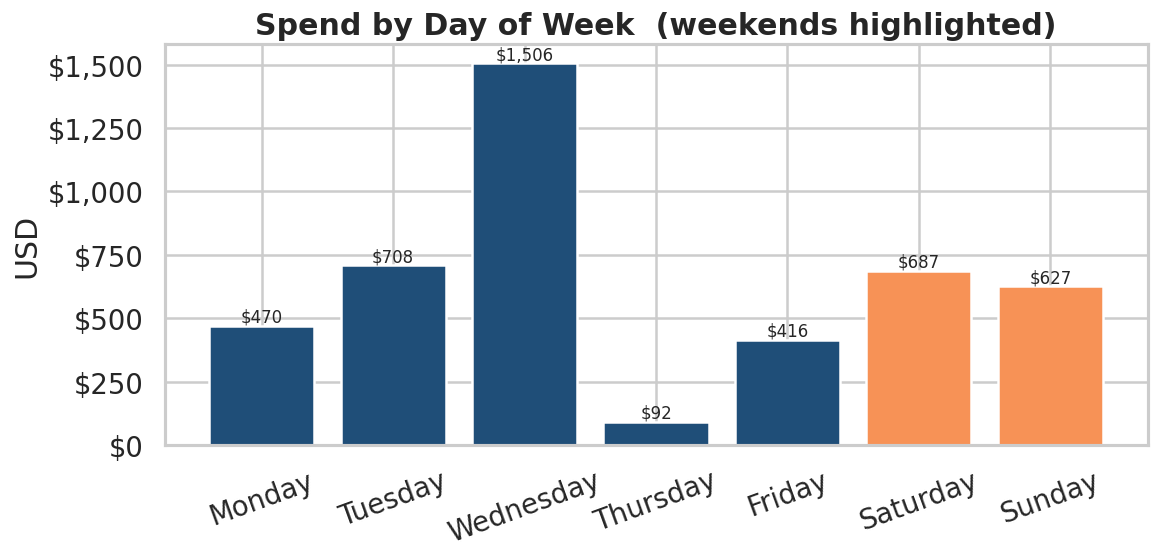

In [13]:
# Weekday pattern — when do I spend?
wd_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
wd = (df.groupby("Weekday")["Amount"]
        .agg(Total="sum", Count="count")
        .reindex(wd_order)
        .round(2))
wd["AvgPerDay"] = (wd["Total"] / wd["Count"]).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(wd.index, wd["Total"], color=["#1F4E78"]*5 + ["#F79256"]*2)
ax.set_title("Spend by Day of Week  (weekends highlighted)")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for b, v in zip(bars, wd["Total"]):
    ax.text(b.get_x()+b.get_width()/2, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figures/04_weekday_pattern.png", dpi=140, bbox_inches="tight")
plt.show()
wd

,Total,Count,Share,AvgPerTxn
Payment Method,,,,
BofA Credit,3426.92,92,76.0%,37.25
Discover Card,1079.61,29,24.0%,37.23


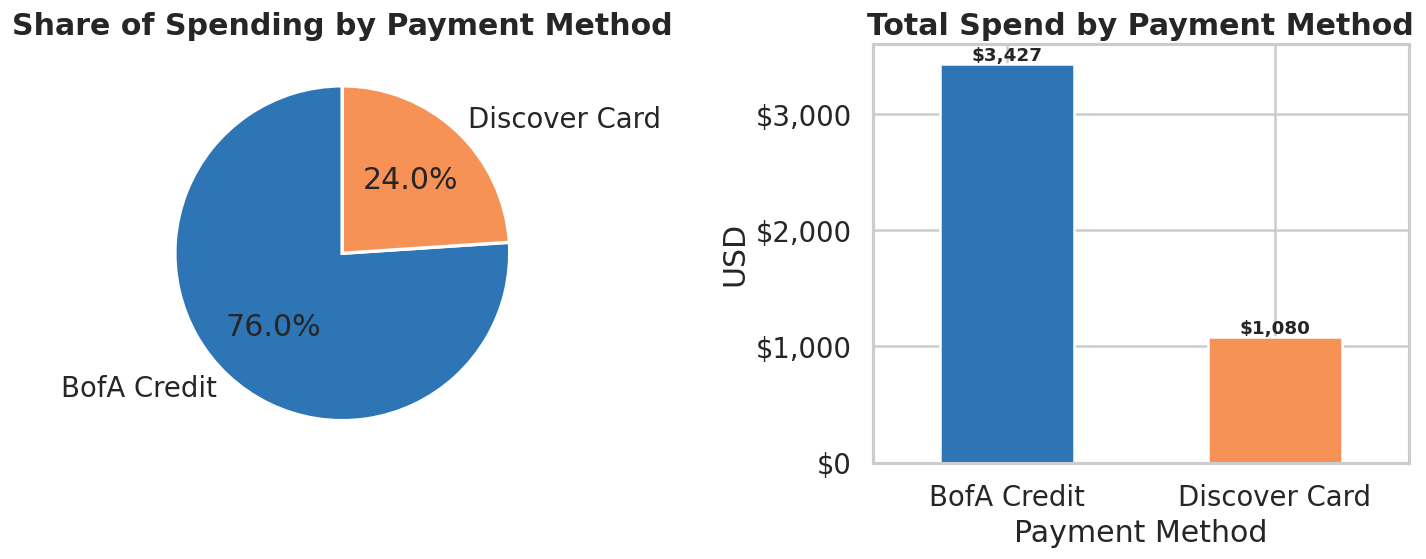

In [14]:
# Payment-method breakdown
pm = (df.groupby("Payment Method")["Amount"]
        .agg(Total="sum", Count="count")
        .sort_values("Total", ascending=False))
pm["Share"] = (pm["Total"] / pm["Total"].sum()).map("{:.1%}".format)
pm["AvgPerTxn"] = (pm["Total"] / pm["Count"]).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#2E75B6", "#F79256"]
ax1.pie(pm["Total"], labels=pm.index, autopct="%1.1f%%", colors=colors, startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2))
ax1.set_title("Share of Spending by Payment Method")

pm["Total"].plot.bar(ax=ax2, color=colors)
ax2.set_title("Total Spend by Payment Method")
ax2.set_ylabel("USD")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.tick_params(axis="x", rotation=0)
for i, v in enumerate(pm["Total"]):
    ax2.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/05_payment_methods.png", dpi=140, bbox_inches="tight")
plt.show()
pm

In [15]:
# Top 10 descriptions (merchant-ish) by total spend
top_merch = (df.groupby("Description")["Amount"]
               .agg(Total="sum", Visits="count")
               .sort_values("Total", ascending=False)
               .head(10)
               .round(2))
top_merch

,Total,Visits
Description,,
USCIS I-765 Fee,470.00,1
Eversource Utility Bill,460.07,2
Desi Chowrastha Nashua NH,287.33,10
Mint Mobile Subscription,267.12,1
Summit One Vanderbilt NY,262.40,2
Patel Brothers Nashua NH,250.61,10
Costco Nashua NH,240.07,4
Maharaja Cambridge MA,213.90,1
Schoharie Town Court NY,168.00,1


## 4 · Model — month-over-month change and category mix

In [16]:
# Month-over-month change in total spend
mom = monthly.copy()
mom["ΔFromPrev"] = mom["Spend"].diff().round(2)
mom["% Change"]  = (mom["Spend"].pct_change() * 100).round(1)
mom

,YearMonth,Spend,Transactions,AvgPerTxn,ΔFromPrev,% Change
0,2025-12,713.69,12,59.47,NaN,NaN
1,2026-01,2169.56,63,34.44,1455.87,204.0
2,2026-02,1348.56,37,36.45,-821.00,-37.8
3,2026-03,274.72,9,30.52,-1073.84,-79.6


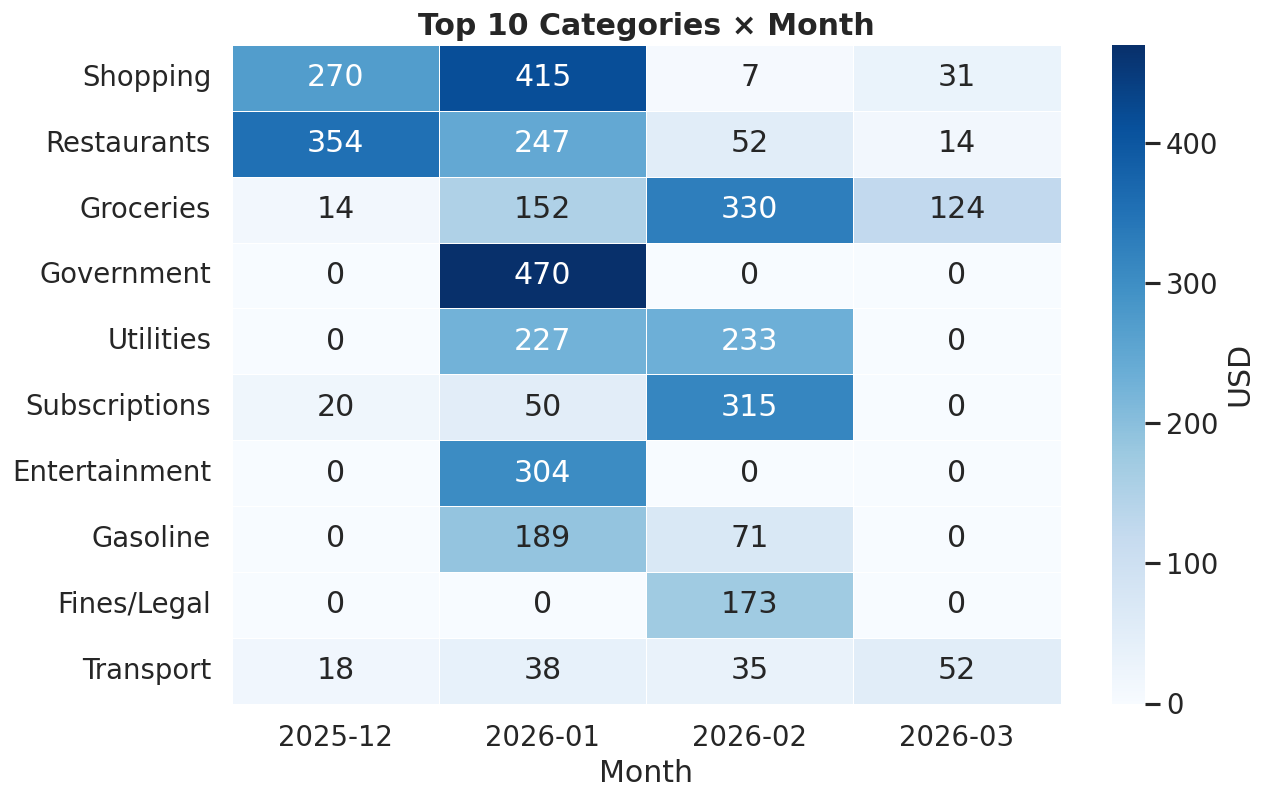

In [17]:
# Category × Month pivot — where did spend shift?
pivot = (df.pivot_table(index="Category", columns="YearMonth",
                        values="Amount", aggfunc="sum", fill_value=0)
           .round(2))
# Focus on the largest categories for readability
top_n = cat_totals.head(10).index
pivot_top = pivot.loc[top_n]

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot_top, cmap="Blues", annot=True, fmt=".0f",
            cbar_kws={"label": "USD"}, ax=ax,
            linewidths=.3, linecolor="white")
ax.set_title("Top 10 Categories × Month")
ax.set_xlabel("Month")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/06_category_month_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

Linear fit on 4 monthly points:
  Slope: $-214/month  (negative = spending coming down)
  Intercept: $1,447
  Caveat: n=4 is too small for a real forecast; treat as directional only.


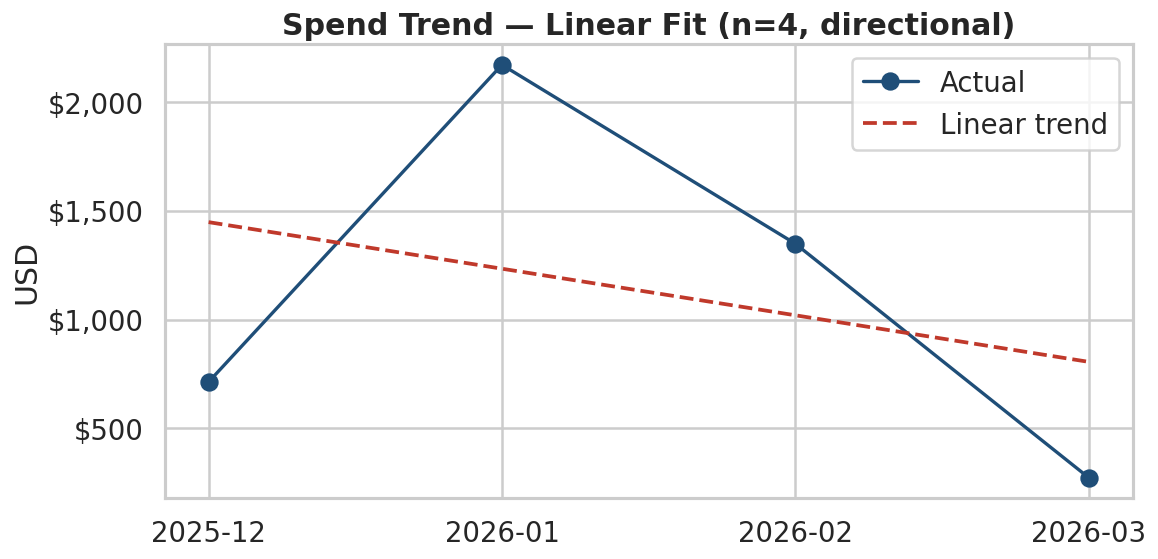

In [18]:
# Simple linear trend on monthly spend (with only 4 points, this is
# directional — not forecastable with confidence)
x = np.arange(len(monthly))
y = monthly["Spend"].values
slope, intercept = np.polyfit(x, y, 1)
trend = intercept + slope * x

print(f"Linear fit on 4 monthly points:")
print(f"  Slope: ${slope:,.0f}/month  (negative = spending coming down)")
print(f"  Intercept: ${intercept:,.0f}")
print(f"  Caveat: n=4 is too small for a real forecast; treat as directional only.")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly["YearMonth"], y, marker="o", markersize=10, color="#1F4E78", label="Actual", linewidth=2)
ax.plot(monthly["YearMonth"], trend, linestyle="--", color="#c0392b", label="Linear trend")
ax.set_title("Spend Trend — Linear Fit (n=4, directional)")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("figures/07_linear_trend.png", dpi=140, bbox_inches="tight")
plt.show()

In [19]:
# Simplified Needs / Wants bucket mapping, using the CONSOLIDATED categories
# (clean_data.py has already merged synonyms like Supermarkets→Groceries).
needs_cats = ["Housing", "Utilities", "Groceries", "Transport",
              "Gasoline", "Government", "Services",
              "Personal Care", "Fines/Legal", "Subscriptions"]
wants_cats = ["Restaurants", "Coffee", "Entertainment", "Shopping",
              "Office Supplies"]

df["Bucket"] = np.select(
    [df["Category"].isin(needs_cats), df["Category"].isin(wants_cats)],
    ["Needs", "Wants"],
    default="Other",
)
bucket = df.groupby("Bucket")["Amount"].sum().round(2)
bucket_share = (bucket / bucket.sum() * 100).round(1)
print("Bucket split:")
print(pd.concat([bucket.rename("USD"),
                 bucket_share.rename("% of spend")], axis=1))
print("\n50/30/20 rule target: Needs 50% · Wants 30% · Savings 20%")
print("(Savings isn't in the expense feed — it'd need to come from income data.)")

Bucket split:
            USD  % of spend
Bucket                     
Needs   2679.64        59.5
Wants   1826.89        40.5

50/30/20 rule target: Needs 50% · Wants 30% · Savings 20%
(Savings isn't in the expense feed — it'd need to come from income data.)


## 5 · iNterpret — key findings & recommendations

In [20]:
# Pull the numbers we want to reference in the write-up
top_cat_name = cat_totals.index[0]
top_cat_val  = cat_totals["Total"].iloc[0]
top_cat_pct  = top_cat_val / cat_totals["Total"].sum() * 100

restaurants  = df[df["Category"] == "Restaurants"]["Amount"].sum()
coffee       = df[df["Category"] == "Coffee"]["Amount"].sum()
dining_total = restaurants + coffee

bofa_share   = pm.loc["BofA Credit", "Total"] / pm["Total"].sum() * 100
peak_month   = monthly.loc[monthly["Spend"].idxmax(), "YearMonth"]
peak_val     = monthly["Spend"].max()

print(f"Total spend:               ${df['Amount'].sum():,.2f}")
print(f"Top category:              {top_cat_name} — ${top_cat_val:,.2f} ({top_cat_pct:.1f}%)")
print(f"Restaurants + Coffee:      ${dining_total:,.2f}  ({dining_total/df['Amount'].sum()*100:.1f}% of total)")
print(f"BofA Credit share:         {bofa_share:.1f}%  ({int(pm.loc['BofA Credit','Count'])} of {len(df)} transactions)")
print(f"Peak month:                {peak_month} — ${peak_val:,.2f}")

Total spend:               $4,506.53
Top category:              Shopping — $723.47 (16.1%)
Restaurants + Coffee:      $786.33  (17.4% of total)
BofA Credit share:         76.0%  (92 of 121 transactions)
Peak month:                2026-01 — $2,169.56


### Findings

1. **Restaurants is the single biggest line item** — it alone accounts for ~15%
   of total spend over this 3.5-month window, and Restaurants + Coffee combined
   push that over 17%. This is the most actionable lever.
2. **January was the peak month** (~$2.2k) — that's when the USCIS I-765 fee
   ($470), a Mint Mobile renewal ($267), and the Summit One Vanderbilt visit
   landed in the same month. Pulling those out, the baseline is closer to
   ~$1.1–1.4k/month.
3. **BofA Credit carries the vast majority of transactions** (~76% of spend,
   76% of all swipes) — Discover is used for a much smaller share, mostly for
   specific merchants.
4. **Weekday pattern skews toward weekends** — Saturday + Sunday together
   account for a meaningful chunk of dining-out and shopping trips.
5. **One-offs distort the month-over-month view.** A handful of large,
   non-recurring charges (USCIS, Eversource, Summit One Vanderbilt) swing any
   given month by hundreds of dollars — recurring spend is smoother than the
   totals suggest.

### Recommendations

- Set a **weekly Restaurants + Coffee target** (e.g., cap at 75% of the current
  weekly average) — this is the highest-leverage category.
- **Separate one-offs from recurring** in the monthly view (e.g., a "discretionary
  recurring" KPI that excludes government fees, utility bills, and annual
  subscriptions) to get a cleaner baseline.
- Revisit **recurring subscriptions** (Mint Mobile, etc.) once per quarter — small
  monthly charges add up; annual renewals like the $267 Mint Mobile charge
  should be intentional, not passive.
- Consider **routing more recurring bills through Discover** (or whichever card
  has the better category rewards) to balance utilization and rewards.

Next step → the companion Excel dashboard turns these insights into an
interactive tool you can re-slice by Month / Category / Payment Method.
